In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install -q gpflow

In [8]:
!pip install -q --upgrade --force-reinstall numpy threadpoolctl scipy scikit-learn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gpflow 2.10.0 requires numpy<2, but you have numpy 2.4.0 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.0 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.0 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.0 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.0 which is incompatible.


In [9]:
import numpy as np
from sklearn.calibration import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import classification_report
import pandas as pd
from datetime import datetime
import gpflow
import tensorflow as tf
import warnings
from prettytable import PrettyTable
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

def print_table(df: pd.DataFrame):
    top_rows = df.copy()
    table = PrettyTable()
    table.field_names = top_rows.columns.tolist()
    for _, row in top_rows.iterrows():
        table.add_row(row.tolist())
    print(table)

In [10]:
# df_audit_grade = pd.read_parquet(r'I:\My Drive\Projects_mdw\BayesAudit\Data\audit_grading.parquet')
df_audit_grade = pd.read_parquet(r'/content/drive/MyDrive/Projects_mdw/BayesAudit/Data/audit_grading.parquet')
print(df_audit_grade.shape)
print(df_audit_grade.columns)
df_audit_grade.head()

(413, 3)
Index(['Site_ID', 'Shop Grade', 'Current Audit Date'], dtype='object')


,Site_ID,Shop Grade,Current Audit Date
0,S001,B,2025-09-11
1,S002,C-,2025-08-11
2,S003,B,2025-05-14
3,S004,A,2025-07-09
4,S005,B,2025-02-06


In [11]:
df_dim_store = df_audit_grade[['Site_ID']]
df_dim_store.drop_duplicates(inplace=True)
print(df_dim_store.shape)
df_dim_store.head()

(413, 1)


,Site_ID
0,S001
1,S002
2,S003
3,S004
4,S005


### Preprocess Audit Grades Data

In [12]:
df_audit_grade['Current Audit Date'] = pd.to_datetime(df_audit_grade['Current Audit Date'])

current_date = df_audit_grade['Current Audit Date'].max()
days_count =  60 # current_date.day + 31 #+30

df_audit_grade = df_audit_grade[(current_date - df_audit_grade['Current Audit Date']).dt.days <= days_count]
print('df_audit_grade shape :',df_audit_grade.shape)
print('df_audit_grade Min date :',df_audit_grade['Current Audit Date'].min())
print('df_audit_grade Max date :',df_audit_grade['Current Audit Date'].max())

df_audit_grade shape : (116, 3)
df_audit_grade Min date : 2025-08-25 00:00:00
df_audit_grade Max date : 2025-10-24 00:00:00


In [13]:
df_kpi_score = pd.read_parquet(r'/content/drive/MyDrive/Projects_mdw/BayesAudit/Data/kpi_scores.parquet')
print(df_kpi_score.shape)
print(df_kpi_score.columns)
df_kpi_score.head()

(58013, 24)
Index(['EDATE', 'INVENTORY_TURNOVER_RTO_RISK_SCORE',
       'PRODUCTRELEASE_COST_RTO_RISK_SCORE',
       'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE', 'PH_NO_CHANGE_CUST_RISK_SCORE',
       'EARL_CLOS_DISCOUNT_RISK_SCORE', 'HIRE_SALE_ASS_ACC_RISK_SCORE',
       'CASHA_RISK_SCORE', 'ACC_LESS_ADD_PAY_RISK_SCORE',
       'ISSUE_RTO_RISK_SCORE', 'cash_coll_vs_banking_rto',
       'UNSALEABLE_INVENTORY_RTO', 'REVERT_INVENTORY_RTO',
       'TOT_UNPAID_CASH_SALES_RISK', 'TOT_HP_ARREARS_RISK_RTO',
       'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN', 'RETURN_CHEQUE_RISK_SCORE',
       'SPECIAL_DISCOUNT_RISK_SCORE', 'MULTI_HP_ACC_PER_CUST_RISK_SCORE',
       'INITIAL_PAYMENT_NOT_PAID_RISK_SCORE', 'SALES_RETURN_RISK_SCORE',
       'PRODUCT_MANUAL_ORDERS_RISK_SCORE', 'SHORT_REMIT_RISK_SCORE',
       'Site_ID'],
      dtype='object')


,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,PH_NO_CHANGE_CUST_RISK_SCORE,EARL_CLOS_DISCOUNT_RISK_SCORE,HIRE_SALE_ASS_ACC_RISK_SCORE,CASHA_RISK_SCORE,ACC_LESS_ADD_PAY_RISK_SCORE,ISSUE_RTO_RISK_SCORE,...,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,RETURN_CHEQUE_RISK_SCORE,SPECIAL_DISCOUNT_RISK_SCORE,MULTI_HP_ACC_PER_CUST_RISK_SCORE,INITIAL_PAYMENT_NOT_PAID_RISK_SCORE,SALES_RETURN_RISK_SCORE,PRODUCT_MANUAL_ORDERS_RISK_SCORE,SHORT_REMIT_RISK_SCORE,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.014951,0.000000,0.000000,0.145757,NaN,0.0,...,0.018022,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.499210,0.000000,0.000000,0.091817,NaN,0.0,...,0.047599,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.210004,0.241084,0.688894,0.414772,NaN,0.0,...,0.013334,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.020825,0.000000,0.863735,0.708144,NaN,0.0,...,0.084018,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.400223,0.272825,0.000000,0.833605,NaN,0.0,...,0.025874,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S478


### Preprocess KPI Scores Data

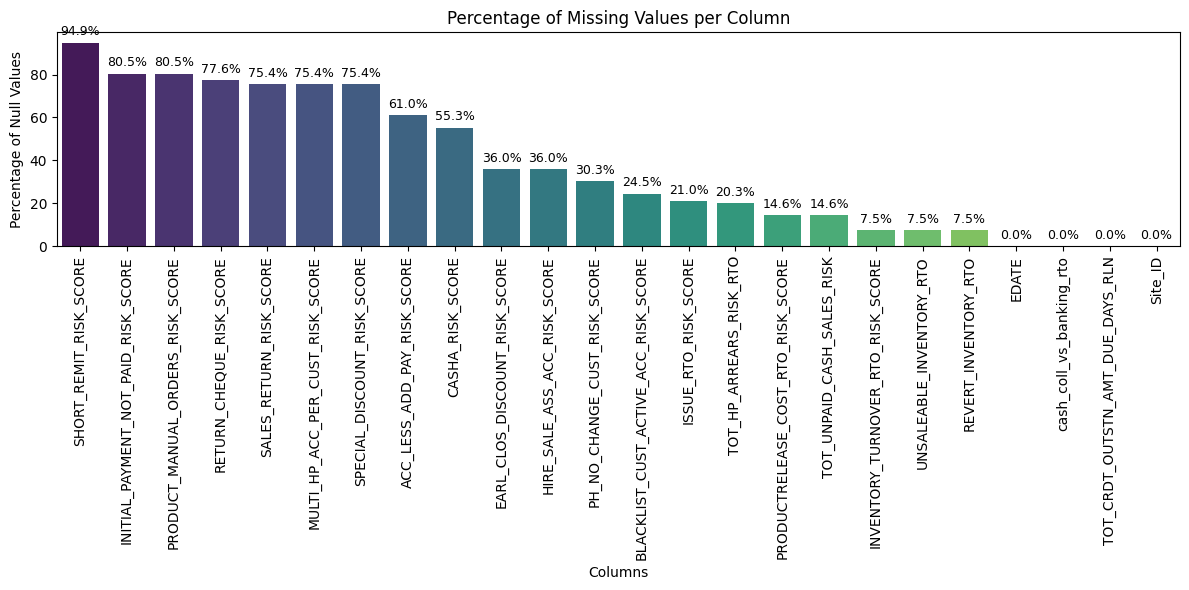

In [14]:
df_kpi_score['EDATE'] = pd.to_datetime(df_kpi_score['EDATE'])
null_df_kpi_score = pd.DataFrame(df_kpi_score.isnull().sum(),columns=['Null_Count'])
null_df_kpi_score['Null_Count'] = (null_df_kpi_score['Null_Count'] / df_kpi_score.shape[0])*100
null_df_kpi_score=null_df_kpi_score.sort_values(by='Null_Count',ascending=False)
# null_df_kpi_score.head(null_df_kpi_score.shape[0])

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=null_df_kpi_score.index,
    y=null_df_kpi_score['Null_Count'],
    palette='viridis'
)
plt.xticks(rotation=90)
plt.ylabel('Percentage of Null Values')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values per Column')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In [15]:
drop_columns = null_df_kpi_score[null_df_kpi_score['Null_Count']>25].index
print(drop_columns)

df_kpi_score.drop(drop_columns,axis=1,inplace=True)
df_kpi_score.head()

Index(['SHORT_REMIT_RISK_SCORE', 'INITIAL_PAYMENT_NOT_PAID_RISK_SCORE',
       'PRODUCT_MANUAL_ORDERS_RISK_SCORE', 'RETURN_CHEQUE_RISK_SCORE',
       'SALES_RETURN_RISK_SCORE', 'MULTI_HP_ACC_PER_CUST_RISK_SCORE',
       'SPECIAL_DISCOUNT_RISK_SCORE', 'ACC_LESS_ADD_PAY_RISK_SCORE',
       'CASHA_RISK_SCORE', 'EARL_CLOS_DISCOUNT_RISK_SCORE',
       'HIRE_SALE_ASS_ACC_RISK_SCORE', 'PH_NO_CHANGE_CUST_RISK_SCORE'],
      dtype='object')


,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,ISSUE_RTO_RISK_SCORE,cash_coll_vs_banking_rto,UNSALEABLE_INVENTORY_RTO,REVERT_INVENTORY_RTO,TOT_UNPAID_CASH_SALES_RISK,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.0,0.0,0.043791,0.047997,0.000000,0.018022,0.0,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.0,0.0,0.016666,0.026522,0.047185,0.047599,0.0,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.0,0.0,0.005226,0.037853,0.000000,0.013334,0.0,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.0,0.0,0.019839,0.092460,0.000000,0.084018,0.0,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.0,0.0,0.001064,0.046433,0.102690,0.025874,0.0,S478


In [ ]:
df_kpi_score.describe()

,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,ISSUE_RTO_RISK_SCORE,cash_coll_vs_banking_rto,UNSALEABLE_INVENTORY_RTO,REVERT_INVENTORY_RTO,TOT_UNPAID_CASH_SALES_RISK,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN
count,58013,53635.000000,49527.000000,43775.000000,45834.000000,58013.000000,53635.000000,53635.000000,49527.000000,4.624500e+04,58013.000000
mean,2025-09-15 11:58:23.938772224,0.612759,0.498328,0.022969,0.003376,0.380537,0.024905,0.086684,0.028091,2.986611e-02,0.032480
min,2025-07-04 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,2025-08-09 00:00:00,0.442154,0.346552,0.000000,0.000000,0.000000,0.002199,0.018424,0.000000,7.584085e-07,0.000000
50%,2025-09-16 00:00:00,0.682829,0.500000,0.004145,0.000000,0.412722,0.006570,0.042325,0.000000,1.067325e-02,0.000000
75%,2025-10-22 00:00:00,0.837366,0.761060,0.013486,0.000000,0.691212,0.013853,0.090245,0.012189,3.963398e-02,0.000000
max,2025-11-28 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,0.999923,0.725785,1.000000,1.000000e+00,1.000000
std,NaN,0.268678,0.301597,0.069870,0.051356,0.344852,0.109364,0.113509,0.082066,6.496344e-02,0.105806


In [ ]:
df_kpi_score.columns

Index(['EDATE', 'INVENTORY_TURNOVER_RTO_RISK_SCORE',
       'PRODUCTRELEASE_COST_RTO_RISK_SCORE',
       'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE', 'ISSUE_RTO_RISK_SCORE',
       'cash_coll_vs_banking_rto', 'UNSALEABLE_INVENTORY_RTO',
       'REVERT_INVENTORY_RTO', 'TOT_UNPAID_CASH_SALES_RISK',
       'TOT_HP_ARREARS_RISK_RTO', 'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN',
       'Site_ID'],
      dtype='object')

### Buid Features

In [ ]:
df_kpi_score.head()

,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,ISSUE_RTO_RISK_SCORE,cash_coll_vs_banking_rto,UNSALEABLE_INVENTORY_RTO,REVERT_INVENTORY_RTO,TOT_UNPAID_CASH_SALES_RISK,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.0,0.0,0.043791,0.047997,0.000000,0.018022,0.0,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.0,0.0,0.016666,0.026522,0.047185,0.047599,0.0,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.0,0.0,0.005226,0.037853,0.000000,0.013334,0.0,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.0,0.0,0.019839,0.092460,0.000000,0.084018,0.0,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.0,0.0,0.001064,0.046433,0.102690,0.025874,0.0,S478


In [ ]:
df_audit_grade.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116 entries, 0 to 407
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Site_ID             116 non-null    object        
 1   Shop Grade          116 non-null    object        
 2   Current Audit Date  116 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 3.6+ KB


In [16]:
feature_df = pd.DataFrame()
sites = df_dim_store['Site_ID'].unique()

for site in sites:
    try:
        audit_date = df_audit_grade[df_audit_grade['Site_ID']==site]['Current Audit Date'].dt.date.values[0]
        audit_grade = df_audit_grade[df_audit_grade['Site_ID']==site]['Shop Grade'].values[0]
    except:
        audit_date = df_kpi_score['EDATE'].max().date()
        audit_grade = None

    sub_score = df_kpi_score[(df_kpi_score ['Site_ID']==site) & (df_kpi_score ['EDATE'].dt.date<=audit_date)]
    sub_score = sub_score.sort_values(by='EDATE',ascending=False)
    sub_score.reset_index(drop=True,inplace=True)

    if sub_score.shape[0]<30:
        print('Skipping No 30 records',site,audit_date,audit_grade)
        continue
    else:
        print(site,audit_date,audit_grade)

    for i in range(0,30):

        rundate = sub_score.loc[i,'EDATE'] if sub_score.shape[0]>0 else None

        if rundate is None:
            print('Rundate is None',site)
            break

        data_dict = {'branch': site,
                    'grade': audit_grade,
                    'day': i+1,
                    'rundate':rundate,
                    'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE':sub_score.loc[i,'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE'],
                    'INVENTORY_TURNOVER_RTO_RISK_SCORE':sub_score.loc[i,'INVENTORY_TURNOVER_RTO_RISK_SCORE'],
                    'PRODUCTRELEASE_COST_RTO_RISK_SCORE':sub_score.loc[i,'PRODUCTRELEASE_COST_RTO_RISK_SCORE'],
                    'ISSUE_RTO_RISK_SCORE':sub_score.loc[i,'ISSUE_RTO_RISK_SCORE'],
                    'cash_coll_vs_banking_rto':sub_score.loc[i,'cash_coll_vs_banking_rto'],
                    'UNSALEABLE_INVENTORY_RTO':sub_score.loc[i,'UNSALEABLE_INVENTORY_RTO'],
                    'REVERT_INVENTORY_RTO':sub_score.loc[i,'REVERT_INVENTORY_RTO'],
                    'TOT_UNPAID_CASH_SALES_RISK':sub_score.loc[i,'TOT_UNPAID_CASH_SALES_RISK'],
                    'TOT_HP_ARREARS_RISK_RTO':sub_score.loc[i,'TOT_HP_ARREARS_RISK_RTO'],
                    'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN':sub_score.loc[i,'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN']
                    }
        feature_df = pd.concat([feature_df, pd.DataFrame([data_dict])],axis=0)

print('feature_df.shape',feature_df.shape)
print_table(feature_df.head())

S001 2025-09-11 B
S002 2025-11-28 None
S003 2025-11-28 None
S004 2025-11-28 None
S005 2025-11-28 None
S006 2025-11-28 None
S008 2025-11-28 None
S009 2025-11-28 None
S011 2025-11-28 None
S012 2025-09-15 A
S013 2025-11-28 None
S014 2025-11-28 None
S015 2025-11-28 None
S016 2025-11-28 None
S017 2025-09-10 A
S019 2025-11-28 None
S020 2025-09-09 B
S021 2025-11-28 None
S022 2025-11-28 None
S023 2025-09-17 A
S024 2025-10-07 A
S025 2025-11-28 None
S026 2025-11-28 None
S027 2025-09-24 B
S028 2025-11-28 None
S029 2025-11-28 None
S030 2025-11-28 None
S031 2025-11-28 None
S032 2025-11-28 None
S033 2025-08-25 A
S034 2025-09-09 A
S035 2025-09-11 A
S036 2025-11-28 None
S037 2025-10-20 A
S039 2025-09-11 B
S040 2025-10-15 B
S041 2025-09-09 B
S042 2025-11-28 None
S043 2025-11-28 None
S044 2025-11-28 None
S045 2025-11-28 None
S046 2025-11-28 None
S047 2025-11-28 None
S048 2025-11-28 None
S049 2025-11-28 None
S050 2025-11-28 None
S051 2025-11-28 None
S052 2025-11-28 None
S053 2025-11-28 None
S054 2025-11-

#### Prepare Training Data

In [17]:
def build_input_matrix(df,feature_cols):
    times = df['day'].values.reshape(-1, 1)
    feats = df[feature_cols].values
    X = np.hstack([times, feats])
    return X.astype(np.float64)

graded_df = feature_df.dropna(subset=['grade']).copy()
graded_df.fillna(0, inplace=True)

ungraded_df = feature_df[feature_df['grade'].isna()].copy()
ungraded_df.fillna(0, inplace=True)

print(f"Graded branches: {graded_df['branch'].nunique()} (out of {feature_df['branch'].nunique()})")
print(f"Total observations: {len(feature_df)}")

# Encode grades
le = LabelEncoder()
y_all = le.fit_transform(feature_df['grade'].fillna('Unknown'))
y_graded = le.transform(graded_df['grade'])
grades = le.classes_[:-1]  # exclude 'Unknown'
print("Grades:", grades)

feature_cols = list(feature_df.drop(columns=['branch','grade','day','rundate']).columns)

X_train = build_input_matrix(graded_df,feature_cols)   # (N_train, 4): [time, f1, f2, f3]
Y_train = y_graded.reshape(-1, 1)         # (N_train, 1)

# Scale time and features separately
scaler_time = StandardScaler()
scaler_feats = StandardScaler()

X_train[:, 0] = scaler_time.fit_transform(X_train[:, 0].reshape(-1, 1)).flatten()
X_train[:, 1:] = scaler_feats.fit_transform(X_train[:, 1:])

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

Graded branches: 116 (out of 411)
Total observations: 12330
Grades: ['A' 'B' 'C' 'C-' 'D' 'D-']
X_train shape: (3480, 11)
Y_train shape: (3480, 1)


#### Buid Bayesian Model

In [18]:
def get_kernel(kernel_name):
    if kernel_name == "RBF":
        return gpflow.kernels.RBF()
    elif kernel_name == "Linear":
        return gpflow.kernels.Linear()
    elif kernel_name == "RBF+Linear":
        return gpflow.kernels.RBF() + gpflow.kernels.Linear()
    elif kernel_name == "RBF*Linear":
        return gpflow.kernels.RBF() * gpflow.kernels.Linear()
    elif kernel_name == "Matern32":
        return gpflow.kernels.Matern32()
    elif kernel_name == "Matern32*Linear":
        return gpflow.kernels.Matern32() * gpflow.kernels.Linear()
    else:
        raise ValueError("Unknown kernel")

def train_svgp_model(X_train, Y_train, kernel, num_classes, num_steps=2000):
    num_inducing = min(100, len(X_train))
    Z = KMeans(n_clusters=num_inducing, random_state=0).fit(X_train).cluster_centers_

    model = gpflow.models.SVGP(
        kernel=kernel,
        likelihood=gpflow.likelihoods.MultiClass(num_classes=num_classes),
        inducing_variable=Z,
        num_latent_gps=num_classes,
        whiten=True
    )

    optimizer = tf.optimizers.Adam(learning_rate=0.01)

    @tf.function
    def optimization_step():
        with tf.GradientTape() as tape:
            loss = -model.elbo((X_train, Y_train))
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    for step in range(num_steps):
        loss = optimization_step()
        if step % 200 == 0:
            print(f"Step {step}, ELBO Loss: {loss.numpy():.4f}")

    return model


def get_prediction(df, model):
    results = []

    for branch in df['branch'].unique():
        branch_df = df[df['branch'] == branch]
        X_test = build_input_matrix(branch_df, feature_cols)

        X_test[:, 0] = scaler_time.transform(X_test[:, 0].reshape(-1, 1)).flatten()
        X_test[:, 1:] = scaler_feats.transform(X_test[:, 1:])

        prob_mean, _ = model.predict_y(X_test)
        prob_branch = prob_mean.numpy().mean(axis=0)

        pred_grade = grades[np.argmax(prob_branch)]

        row = {'branch': branch, 'predicted_grade': pred_grade}
        for i, g in enumerate(grades):
            row[f'prob_{g}'] = prob_branch[i]

        results.append(row)

    return pd.DataFrame(results)


In [19]:
kernel_names = [
    "RBF",
    "Linear",
    "RBF+Linear",
    "RBF*Linear",
    "Matern32",
    "Matern32*Linear"
]

results_summary = []

for kname in kernel_names:
    print(f"\n===== Training with Kernel: {kname} =====")

    kernel = get_kernel(kname)
    model = train_svgp_model(
        X_train,
        Y_train,
        kernel=kernel,
        num_classes=len(grades),
        num_steps=2000
    )

    graded_pred = get_prediction(graded_df, model)

    site_acc = graded_df[['branch', 'grade']].drop_duplicates()
    site_acc = site_acc.merge(
        graded_pred[['branch', 'predicted_grade']],
        on='branch',
        how='left'
    )

    report = classification_report(
        site_acc['grade'],
        site_acc['predicted_grade'],
        output_dict=True
    )

    results_summary.append({
        "kernel": kname,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"]
    })



===== Training with Kernel: RBF =====


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x79bac05ba020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


Step 0, ELBO Loss: 24700.5265
Step 200, ELBO Loss: 8319.2213
Step 400, ELBO Loss: 7085.9165
Step 600, ELBO Loss: 6894.5253
Step 800, ELBO Loss: 6791.2834
Step 1000, ELBO Loss: 6650.9761
Step 1200, ELBO Loss: 6610.6388
Step 1400, ELBO Loss: 6496.1402
Step 1600, ELBO Loss: 6476.2763
Step 1800, ELBO Loss: 6440.6998

===== Training with Kernel: Linear =====
Step 0, ELBO Loss: 24700.5265
Step 200, ELBO Loss: 12450.2595
Step 400, ELBO Loss: 12173.3756
Step 600, ELBO Loss: 12017.2106
Step 800, ELBO Loss: 11983.1803
Step 1000, ELBO Loss: 11977.3239
Step 1200, ELBO Loss: 11969.8608
Step 1400, ELBO Loss: 11972.4231
Step 1600, ELBO Loss: 11968.6509
Step 1800, ELBO Loss: 11968.7827

===== Training with Kernel: RBF+Linear =====
Step 0, ELBO Loss: 24700.5265
Step 200, ELBO Loss: 8261.6913
Step 400, ELBO Loss: 6810.5784
Step 600, ELBO Loss: 6619.0075
Step 800, ELBO Loss: 6546.5953
Step 1000, ELBO Loss: 6487.6784
Step 1200, ELBO Loss: 6428.6319
Step 1400, ELBO Loss: 6368.6636
Step 1600, ELBO Loss: 632

In [20]:
results_df = pd.DataFrame(results_summary)
print(results_df.sort_values("macro_f1", ascending=False))

            kernel  accuracy  macro_f1
2       RBF+Linear  0.862069  0.804978
0              RBF  0.853448  0.637334
5  Matern32*Linear  0.853448  0.637334
3       RBF*Linear  0.844828  0.632553
4         Matern32  0.844828  0.505315
1           Linear  0.612069  0.445383


In [ ]:
*

In [ ]:
from tqdm import trange,tqdm

kernel = gpflow.kernels.RBF() * gpflow.kernels.Linear()  # multiplicative interaction
num_inducing = min(100, len(X_train) )
kmeans = KMeans(n_clusters=num_inducing, random_state=0).fit(X_train)
Z = kmeans.cluster_centers_
model = gpflow.models.SVGP(
    kernel=kernel,
    likelihood=gpflow.likelihoods.MultiClass(num_classes=len(grades)),
    inducing_variable=Z,
    num_latent_gps=len(grades),  # one latent per class
    whiten=True
)
gpflow.set_trainable(model.q_mu, True)
gpflow.set_trainable(model.q_sqrt, True)

def objective_closure():
    return -model.elbo((X_train, Y_train))

adam = tf.optimizers.Adam(learning_rate=0.01)

for step in trange(2000, desc="Adam training"):
    with tf.GradientTape() as tape:
        loss = objective_closure()
    grads = tape.gradient(loss, model.trainable_variables)
    adam.apply_gradients(zip(grads, model.trainable_variables))

    if step % 50 == 0:
        tqdm.write(f"Step {step} | Loss: {loss.numpy():.4f}")

opt = gpflow.optimizers.Scipy()
opt.minimize(objective_closure, model.trainable_variables, options=dict(maxiter=2000))

model = model
print("Training complete.")

Adam training:   0%|          | 2/2000 [00:00<06:03,  5.50it/s]

Step 0 | Loss: 24700.5265


Adam training:   3%|▎         | 51/2000 [00:09<07:27,  4.35it/s]

Step 50 | Loss: 17288.4907


Adam training:   5%|▌         | 102/2000 [00:18<05:43,  5.52it/s]

...

Step 1900 | Loss: 6422.2778


Adam training:  98%|█████████▊| 1952/2000 [06:09<00:08,  5.43it/s]

Step 1950 | Loss: 6414.3350


Adam training: 100%|██████████| 2000/2000 [06:18<00:00,  5.28it/s]


Training complete.


#### Inference

In [ ]:
def get_prediction(df):
    results = []

    for branch in df['branch'].unique():
        branch_df = df[df['branch'] == branch]
        X_test = build_input_matrix(branch_df,feature_cols)

        # Scale using training scalers
        X_test[:, 0] = scaler_time.transform(X_test[:, 0].reshape(-1, 1)).flatten()
        X_test[:, 1:] = scaler_feats.transform(X_test[:, 1:])

        # Predict mean probabilities per time point
        prob_mean, prob_var = model.predict_y(X_test)
        prob_per_point = prob_mean.numpy()  # Already softmaxed probabilities for each class

        # Aggregate over time: mean probability per grade
        prob_branch = prob_per_point.mean(axis=0)
        pred_grade = grades[np.argmax(prob_branch)]

        # Store
        row = {'branch': branch, 'predicted_grade': pred_grade}
        for i, g in enumerate(grades):
            row[f'prob_{g}'] = prob_branch[i]
        results.append(row)

    results_df = pd.DataFrame(results)
    print_table(results_df.head())
    return results_df

ungraded_df_result = get_prediction(ungraded_df)
print(ungraded_df_result.shape)
graded_df_result = get_prediction(graded_df)
print(graded_df_result.shape)

+--------+-----------------+----------------------+------------------------+------------------------+------------------------+------------------------+-----------------------+
| branch | predicted_grade |        prob_A        |         prob_B         |         prob_C         |        prob_C-         |         prob_D         |        prob_D-        |
+--------+-----------------+----------------------+------------------------+------------------------+------------------------+------------------------+-----------------------+
|  S002  |        C        | 0.01565042214323591  | 0.00020000014752214073 |   0.982194390743675    | 0.00021227547038342155 | 0.0014913482753687258  | 0.0002475789773295885 |
|  S003  |        A        |  0.9966807149229825  | 0.00020048857942246958 |  0.000200000000483083  | 0.00020065584447950647 |  0.002483711158089092  | 0.0002351213581527782 |
|  S004  |        B        | 0.022212374740831767 |   0.9104812225701617   |  0.041908154076085294  |  0.008240007488053

#### Evaluate Result

In [ ]:
def evaluate_train_result(results_df):
    site_acc = graded_df[['branch','grade']]
    site_acc.drop_duplicates(inplace=True)
    print(site_acc.shape)
    print('graded_df value count\n',site_acc['grade'].value_counts())

    print('results_df value count\n',results_df['predicted_grade'].value_counts())

    site_acc = site_acc.merge(results_df[['branch', 'predicted_grade']], on='branch', how='left')
    print(classification_report(site_acc['grade'], site_acc['predicted_grade']))

evaluate_train_result(graded_df_result)

print('ungraded_df_result.shape',ungraded_df_result.shape)
print('graded_df_result.shape',graded_df_result.shape)

(116, 2)
graded_df value count
 grade
A     71
B     31
C      6
D      4
C-     3
D-     1
Name: count, dtype: int64
results_df value count
 predicted_grade
A     85
B     23
C      4
D      3
C-     1
Name: count, dtype: int64
              precision    recall  f1-score   support

           A       0.82      0.99      0.90        71
           B       0.87      0.65      0.74        31
           C       1.00      0.67      0.80         6
          C-       1.00      0.33      0.50         3
           D       1.00      0.75      0.86         4
          D-       0.00      0.00      0.00         1

    accuracy                           0.84       116
   macro avg       0.78      0.56      0.63       116
weighted avg       0.85      0.84      0.83       116

ungraded_df_result.shape (295, 8)
graded_df_result.shape (116, 8)


In [ ]:
df_dim_store.head()

,Site_ID
0,S001
1,S002
2,S003
3,S004
4,S005


In [ ]:
ungraded_df_result.rename(columns={'branch':'Site_ID'},inplace=True)
df_final = df_dim_store.merge(ungraded_df_result[['Site_ID','predicted_grade']],on='Site_ID',how='left')
df_final['Rundate'] = datetime.today()

df_audit_grade.rename(columns={'Shop Code':'Site_ID',
                                    'Current Audit Date':'Last_Audit_Date',
                                    'Shop Grade':'Last_Audit_Grade'
                                    },inplace=True)
df_final = df_final.merge(df_audit_grade[['Site_ID','Last_Audit_Grade','Last_Audit_Date']],on='Site_ID',how='left')
print('END OF THE PIPELINE..................')

END OF THE PIPELINE..................


In [ ]:
print(df_final['Site_ID'].nunique())
df_final.isnull().sum()

413


,0
Site_ID,0
predicted_grade,118
Rundate,0
Last_Audit_Grade,297
Last_Audit_Date,297


In [ ]:
print_table(df_final.sample(50))

+---------+-----------------+----------------------------+------------------+---------------------+
| Site_ID | predicted_grade |          Rundate           | Last_Audit_Grade |   Last_Audit_Date   |
+---------+-----------------+----------------------------+------------------+---------------------+
|   S400  |       nan       | 2025-12-29 15:23:28.293752 |        B         | 2025-10-09 00:00:00 |
|   S342  |       nan       | 2025-12-29 15:23:28.293752 |        A         | 2025-09-19 00:00:00 |
|   S467  |       nan       | 2025-12-29 15:23:28.293752 |        B         | 2025-10-21 00:00:00 |
|   S207  |       nan       | 2025-12-29 15:23:28.293752 |        A         | 2025-09-08 00:00:00 |
|   S315  |        A        | 2025-12-29 15:23:28.293752 |       nan        |         NaT         |
|   S433  |        B        | 2025-12-29 15:23:28.293752 |       nan        |         NaT         |
|   S044  |        B        | 2025-12-29 15:23:28.293752 |       nan        |         NaT         |
